In [ ]:

!pip install transformers -q

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from transformers import SwinForImageClassification

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
BATCH_SIZE = 32
EPOCHS = 5
LR_PRETRAINED = 2e-5
LR_SCRATCH = 0.001
NUM_CLASSES = 100

QUICK_TEST = False
QUICK_SUBSET_SIZE = 1000
QUICK_EPOCHS = 1

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

CIFAR100_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR100_STD = (0.2673, 0.2564, 0.2762)

#  Pretrained Swin transforms (224x224, ImageNet stats)
transform_pretrained_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
transform_pretrained_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

#  Scratch Swin transforms (native 32x32, CIFAR-100 stats)
transform_scratch_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])
transform_scratch_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

DATA_ROOT = "./data"


def build_loaders(transform_train, transform_test, batch_size):
    train_set = torchvision.datasets.CIFAR100(root=DATA_ROOT, train=True, download=True, transform=transform_train)
    test_set = torchvision.datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=transform_test)

    epochs = EPOCHS
    if QUICK_TEST:
        train_set = torch.utils.data.Subset(train_set, range(QUICK_SUBSET_SIZE))
        test_set = torch.utils.data.Subset(test_set, range(QUICK_SUBSET_SIZE // 4))
        epochs = QUICK_EPOCHS

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader, epochs


pretrained_train_loader, pretrained_test_loader, run_epochs = build_loaders(
    transform_pretrained_train, transform_pretrained_test, BATCH_SIZE
)
scratch_train_loader, scratch_test_loader, _ = build_loaders(
    transform_scratch_train, transform_scratch_test, BATCH_SIZE
)

print(f"Epochs this run: {run_epochs}")
print(f"Pretrained-pipeline train/test batches: {len(pretrained_train_loader)}/{len(pretrained_test_loader)}")
print(f"Scratch-pipeline train/test batches: {len(scratch_train_loader)}/{len(scratch_test_loader)}")

100%|██████████| 169M/169M [42:34<00:00, 66.2kB/s]


Epochs this run: 5
Pretrained-pipeline train/test batches: 1563/313
Scratch-pipeline train/test batches: 1563/313


In [ ]:
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows


def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = q * self.scale
        attn = q @ k.transpose(-2, -1)
        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class SwinBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=4, shift_size=0, mlp_ratio=4.0,
                 qkv_bias=True, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.input_resolution = input_resolution
        self.window_size = window_size
        self.shift_size = shift_size

        # If the feature map is no larger than the window, there's nothing to
        # shift/window -- fall back to a single global window over the map.
        if min(self.input_resolution) <= self.window_size:
            self.shift_size = 0
            self.window_size = min(self.input_resolution)

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, self.window_size, num_heads, qkv_bias, attn_drop, drop)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(mlp_hidden, dim), nn.Dropout(drop),
        )

        if self.shift_size > 0:
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))
            h_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))
            w_slices = (slice(0, -self.window_size), slice(-self.window_size, -self.shift_size), slice(-self.shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mask_windows = window_partition(img_mask, self.window_size).view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None
        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2)) if self.shift_size > 0 else x

        x_windows = window_partition(shifted_x, self.window_size).view(-1, self.window_size * self.window_size, C)
        attn_windows = self.attn(x_windows, mask=self.attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)

        x = torch.roll(shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2)) if self.shift_size > 0 else shifted_x
        x = x.view(B, H * W, C)

        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x


class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.input_resolution = input_resolution
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        x0, x1, x2, x3 = x[:, 0::2, 0::2, :], x[:, 1::2, 0::2, :], x[:, 0::2, 1::2, :], x[:, 1::2, 1::2, :]
        x = torch.cat([x0, x1, x2, x3], -1).view(B, -1, 4 * C)
        x = self.norm(x)
        return self.reduction(x)


class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=2, in_chans=3, embed_dim=96):
        super().__init__()
        self.grid_size = img_size // patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        return self.norm(x)


class BasicLayer(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads, window_size, mlp_ratio=4.0, downsample=None):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinBlock(dim, input_resolution, num_heads, window_size,
                      shift_size=0 if (i % 2 == 0) else window_size // 2, mlp_ratio=mlp_ratio)
            for i in range(depth)
        ])
        self.downsample = downsample(input_resolution, dim) if downsample is not None else None

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        if self.downsample is not None:
            x = self.downsample(x)
        return x


class SwinTransformerScratch(nn.Module):
    def __init__(self, img_size=32, patch_size=2, in_chans=3, num_classes=100,
                 embed_dim=96, depths=(2, 2, 6, 2), num_heads=(3, 6, 12, 24), window_size=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        grid = self.patch_embed.grid_size

        self.layers = nn.ModuleList()
        dim, res = embed_dim, grid
        for i in range(len(depths)):
            layer_window = min(window_size, res)
            downsample = PatchMerging if i < len(depths) - 1 else None
            self.layers.append(BasicLayer(dim, (res, res), depths[i], num_heads[i], layer_window, mlp_ratio, downsample))
            if downsample is not None:
                dim *= 2
                res //= 2

        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

In [ ]:
class HFClassifierWrapper(nn.Module):
    """Wraps a Hugging Face image classification model so forward() returns
    a plain logits tensor, matching the interface of the scratch model."""
    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model

    def forward(self, x):
        return self.hf_model(pixel_values=x).logits


def load_swin_pretrained(model_name, num_classes=100, freeze_backbone=True):
    hf_model = SwinForImageClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
    )
    if freeze_backbone:
        for name, param in hf_model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False
    return HFClassifierWrapper(hf_model)

In [ ]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def train_model(model, model_name, train_loader, test_loader, epochs, lr, device):
    model = model.to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accuracies, epoch_times = [], [], []

    for epoch in range(epochs):
        model.train()
        start = time.time()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_time = time.time() - start
        epoch_times.append(epoch_time)
        train_losses.append(running_loss / len(train_loader.dataset))

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        acc = 100.0 * correct / total
        test_accuracies.append(acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} "
              f"| Test Acc: {acc:.2f}% | Epoch Time: {epoch_time:.1f}s")

    return {
        "model_name": model_name,
        "train_losses": train_losses,
        "test_accuracies": test_accuracies,
        "epoch_times": epoch_times,
        "final_test_acc": test_accuracies[-1],
        "best_test_acc": max(test_accuracies),
        "avg_epoch_time": float(np.mean(epoch_times)),
        "total_train_time": float(np.sum(epoch_times)),
    }

In [ ]:
print(f"{'='*70}\n Fine-tuning Swin-Tiny (pretrained, frozen backbone) \n{'='*70}")

swin_tiny = load_swin_pretrained("microsoft/swin-tiny-patch4-window7-224", NUM_CLASSES, freeze_backbone=True)
tiny_total, tiny_trainable = count_params(swin_tiny)

results = []
tiny_result = train_model(swin_tiny, "Swin-Tiny (pretrained)", pretrained_train_loader, pretrained_test_loader,
                           epochs=run_epochs, lr=LR_PRETRAINED, device=device)
tiny_result.update({"architecture": "Swin-Tiny (pretrained)", "total_params": tiny_total, "trainable_params": tiny_trainable})
results.append(tiny_result)

del swin_tiny
if device.type == "cuda":
    torch.cuda.empty_cache()

 Fine-tuning Swin-Tiny (pretrained, frozen backbone) 


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


[Swin-Tiny (pretrained)] Epoch 1/5 | Loss: 4.0677 | Test Acc: 46.51% | Epoch Time: 106.0s
[Swin-Tiny (pretrained)] Epoch 2/5 | Loss: 3.0665 | Test Acc: 58.55% | Epoch Time: 108.9s
[Swin-Tiny (pretrained)] Epoch 3/5 | Loss: 2.3840 | Test Acc: 62.52% | Epoch Time: 111.4s
[Swin-Tiny (pretrained)] Epoch 4/5 | Loss: 1.9480 | Test Acc: 64.78% | Epoch Time: 111.1s
[Swin-Tiny (pretrained)] Epoch 5/5 | Loss: 1.6747 | Test Acc: 66.33% | Epoch Time: 111.1s


In [ ]:
print(f"{'='*70}\n Fine-tuning Swin-Small (pretrained, frozen backbone) \n{'='*70}")

swin_small = load_swin_pretrained("microsoft/swin-small-patch4-window7-224", NUM_CLASSES, freeze_backbone=True)
small_total, small_trainable = count_params(swin_small)

small_result = train_model(swin_small, "Swin-Small (pretrained)", pretrained_train_loader, pretrained_test_loader,
                            epochs=run_epochs, lr=LR_PRETRAINED, device=device)
small_result.update({"architecture": "Swin-Small (pretrained)", "total_params": small_total, "trainable_params": small_trainable})
results.append(small_result)

del swin_small
if device.type == "cuda":
    torch.cuda.empty_cache()

 Fine-tuning Swin-Small (pretrained, frozen backbone) 


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

[Swin-Small (pretrained)] Epoch 1/5 | Loss: 3.9992 | Test Acc: 53.05% | Epoch Time: 187.6s
[Swin-Small (pretrained)] Epoch 2/5 | Loss: 2.9019 | Test Acc: 63.17% | Epoch Time: 187.6s
[Swin-Small (pretrained)] Epoch 3/5 | Loss: 2.1771 | Test Acc: 66.75% | Epoch Time: 187.6s
[Swin-Small (pretrained)] Epoch 4/5 | Loss: 1.7414 | Test Acc: 68.67% | Epoch Time: 187.6s
[Swin-Small (pretrained)] Epoch 5/5 | Loss: 1.4800 | Test Acc: 70.24% | Epoch Time: 189.5s


In [ ]:
print(f"{'='*70}\n Training Swin from scratch \n{'='*70}")

swin_scratch = SwinTransformerScratch(num_classes=NUM_CLASSES)
scratch_total, scratch_trainable = count_params(swin_scratch)

scratch_result = train_model(swin_scratch, "Swin (scratch)", scratch_train_loader, scratch_test_loader,
                              epochs=run_epochs, lr=LR_SCRATCH, device=device)
scratch_result.update({"architecture": "Swin (scratch)", "total_params": scratch_total, "trainable_params": scratch_trainable})
results.append(scratch_result)

del swin_scratch
if device.type == "cuda":
    torch.cuda.empty_cache()

 Training Swin from scratch 
[Swin (scratch)] Epoch 1/5 | Loss: 4.6036 | Test Acc: 2.74% | Epoch Time: 65.9s
[Swin (scratch)] Epoch 2/5 | Loss: 4.5890 | Test Acc: 1.00% | Epoch Time: 65.4s
[Swin (scratch)] Epoch 3/5 | Loss: 4.6148 | Test Acc: 1.00% | Epoch Time: 67.2s
[Swin (scratch)] Epoch 4/5 | Loss: 4.6119 | Test Acc: 1.00% | Epoch Time: 65.0s
[Swin (scratch)] Epoch 5/5 | Loss: 4.6106 | Test Acc: 1.00% | Epoch Time: 67.3s


In [ ]:
summary_df = pd.DataFrame([{
    "Model": r["model_name"],
    "Total Params (M)": round(r["total_params"] / 1e6, 2),
    "Trainable Params (M)": round(r["trainable_params"] / 1e6, 2),
    "Final Test Acc (%)": round(r["final_test_acc"], 2),
    "Best Test Acc (%)": round(r["best_test_acc"], 2),
    "Avg Epoch Time (s)": round(r["avg_epoch_time"], 1),
    "Total Train Time (s)": round(r["total_train_time"], 1),
} for r in results])

summary_df = summary_df.sort_values("Final Test Acc (%)", ascending=False).reset_index(drop=True)
summary_df

,Model,Total Params (M),Trainable Params (M),Final Test Acc (%),Best Test Acc (%),Avg Epoch Time (s),Total Train Time (s)
0,Swin-Small (pretrained),48.91,0.08,70.24,70.24,188.0,940.0
1,Swin-Tiny (pretrained),27.60,0.08,66.33,66.33,109.7,548.5
2,Swin (scratch),27.57,27.57,1.00,2.74,66.2,330.8


In [ ]:
summary_df.to_csv("problem2_summary_results.csv", index=False)
print(summary_df.to_markdown(index=False))

| Model                   |   Total Params (M) |   Trainable Params (M) |   Final Test Acc (%) |   Best Test Acc (%) |   Avg Epoch Time (s) |   Total Train Time (s) |
|:------------------------|-------------------:|-----------------------:|---------------------:|--------------------:|---------------------:|-----------------------:|
| Swin-Small (pretrained) |              48.91 |                   0.08 |                70.24 |               70.24 |                188   |                  940   |
| Swin-Tiny (pretrained)  |              27.6  |                   0.08 |                66.33 |               66.33 |                109.7 |                  548.5 |
| Swin (scratch)          |              27.57 |                  27.57 |                 1    |                2.74 |                 66.2 |                  330.8 |


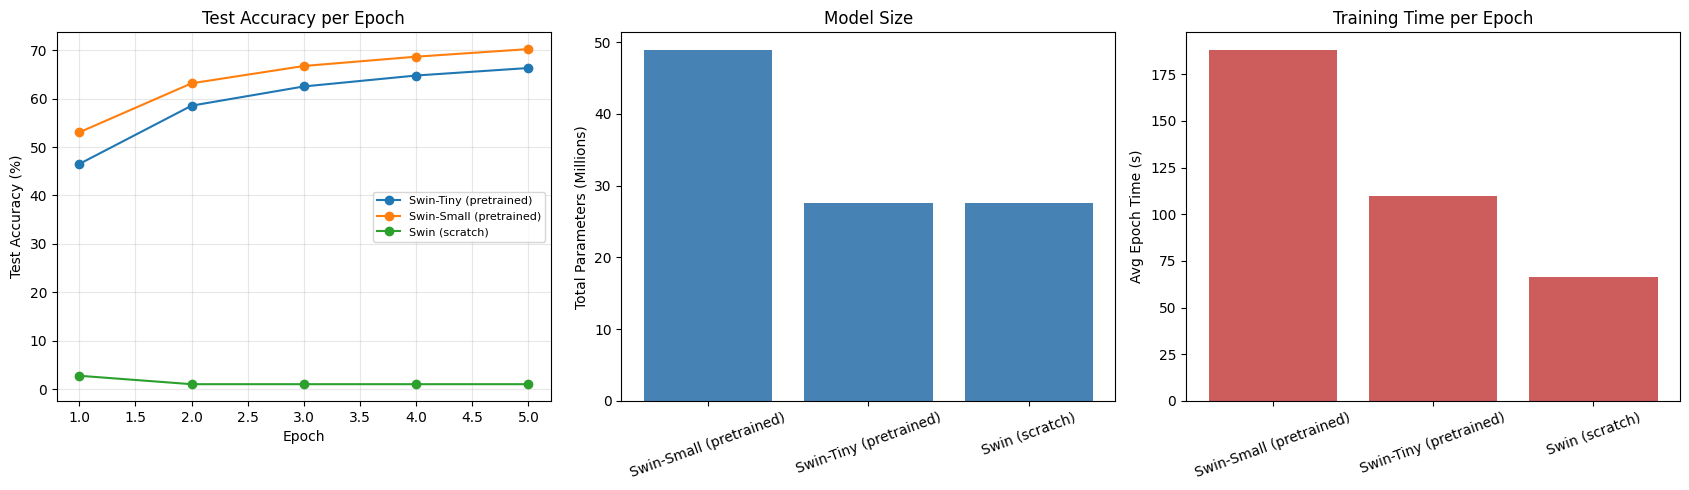

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for r in results:
    axes[0].plot(range(1, len(r["test_accuracies"]) + 1), r["test_accuracies"], marker="o", label=r["model_name"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_title("Test Accuracy per Epoch")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].bar(summary_df["Model"], summary_df["Total Params (M)"], color="steelblue")
axes[1].set_ylabel("Total Parameters (Millions)")
axes[1].set_title("Model Size")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(summary_df["Model"], summary_df["Avg Epoch Time (s)"], color="indianred")
axes[2].set_ylabel("Avg Epoch Time (s)")
axes[2].set_title("Training Time per Epoch")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("problem2_comparison_plots.png", dpi=150)
plt.show()